# Performance Analysis - Study 2a

## Loading the libraries

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import pandas_datareader.data as web
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt
import itertools
from scipy import stats

## Loading the data

In [2]:
df = pd.read_csv('./data/ageRisk_long.csv', index_col=0)

## Fetching performance data & calculating performance measures

In [3]:
start_date = '2023-07-01'
end_date = '2024-01-01' # we calculate the performance over the 6 month following the financial advice data collection
market_data = {}

def fetch_risk_free_rate():
    risk_free_data = web.DataReader("DGS10", "fred").loc[start_date:end_date]
    risk_free_rate = risk_free_data.mean() / 100
    risk_free_rate = risk_free_rate['DGS10']
    return risk_free_rate
    
risk_free_rate = fetch_risk_free_rate()

In [ ]:
def calculate_sharpe_ratio(row):
    if (row['portfolio_std_dev'] == 0) & (row['portfolio_return'] == 0):
        return np.nan
    sharpe = (row['portfolio_return'] - risk_free_rate) / row['portfolio_std_dev']
    return sharpe

def get_market_data(tickers):
    for ticker in tickers:
        try:
            prices = yf.download(ticker, start=start_date, end=end_date)['Adj Close']
            market_data[ticker] = prices
        except:
            market_data[ticker] = pd.Series([1 for _ in range(len(market_data[next(iter(market_data))]))], 
                                              index=market_data[next(iter(market_data))].index) 

def get_portfolio_data(df, group_cols):
    get_market_data(df['ticker_symbol'].dropna().unique())
    portfolio_df = pd.DataFrame(columns=['ai', 'age', 'risk-taking', 'cond', 'iteration', 'portfolio_return', 'portfolio_std_dev'])
    grouped = df.groupby(group_cols)
    
    for name, group in grouped:
        total_investment = group['amount_to_invest'].sum()
        weights = group['amount_to_invest'] / total_investment
        prices_df = pd.DataFrame()
        for i, ticker in enumerate(group['ticker_symbol']):
            if ticker in market_data:
                prices_df[ticker] = market_data[ticker]
            else:
                # Assume no return and no standard deviation for invalid/ Nan tickers
                prices_df[f'{ticker}_{i}'] = pd.Series([1 for _ in range(len(market_data[next(iter(market_data))]))], 
                                              index=market_data[next(iter(market_data))].index)
            
        prices_df = prices_df.ffill().bfill().fillna(1) # fill the price value for equities on the weekend with the last price for portfolios with cryptos 

        # Calculate the cumulative portfolio return
        cumulative_returns = (prices_df.iloc[-1] / prices_df.iloc[0]) - 1
        weights.index = cumulative_returns.index
        portfolio_return = (cumulative_returns * weights).sum()

        # Calculate the portfolio volatilty
        returns_df = prices_df.pct_change()
        cov_matrix = returns_df.cov()
        portfolio_variance = np.dot(weights.T, np.dot(cov_matrix, weights))
        portfolio_std_dev = np.sqrt(portfolio_variance)
        portfolio_df.loc[len(portfolio_df)] = {
            'ai': name[0],
            'age': name[1],
            'risk-taking': name[2],
            'cond': name[3],
            'iteration': name[4],
            'portfolio_return': portfolio_return,
            'portfolio_std_dev': portfolio_std_dev
        }
    return portfolio_df
        
group_cols = ['ai', 'age', 'risk-taking', 'cond', 'iteration']    
portfolio_df = get_portfolio_data(df, group_cols)
portfolio_df['sharpe'] = portfolio_df.apply(calculate_sharpe_ratio, axis=1)
portfolio_df.to_csv('./data/performance_features.csv')


## Analysis

In [4]:
portfolio_df = pd.read_csv('./data/performance_features.csv', index_col=0)
portfolio_df['risk-taking'] = portfolio_df['risk-taking'].replace({'averse':'low', 'neutral':'medium', 'seeking':'high'})
portfolio_df['cond'] = portfolio_df['cond'].replace({'control':'Control prompt', 'engineered':'Debiased prompt'})
portfolio_df['portfolio_std_dev'] *= 100 # in %
portfolio_df['portfolio_return'] *= 100 # in %

In [5]:
label_dict = {'cond':'Condition', 'age':'Age', 'risk-taking':'Risk Tendency'}

def fetch_benchmark_data(ticker):
    prices = yf.download(ticker, start=start_date, end=end_date)['Adj Close']
    cumulative_return = (prices.iloc[-1] / prices.iloc[0]) - 1
    returns_df = prices.pct_change()
    std_dev = returns_df.std()
    sharpe = (cumulative_return - risk_free_rate) / std_dev
    return cumulative_return, std_dev, sharpe

def show_anova(df, column, group1, group2=None):
    if group1 and group2:
        df['label'] = df.apply(lambda row: f"({row[group1]}, {row[group2]})", axis=1)
    else:
        df['label'] = df[group1]
        
    model = ols(f'{column} ~ label', data=df).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    print(anova_table)
    tukey_results = pairwise_tukeyhsd(endog=df[column], groups=df['label'], alpha=0.05)
    print(tukey_results)

def show_ttest(raw, column, groups, benchmark):
    for group_name, group_data in raw.groupby(groups, observed=False):
        group_values = group_data[column]
        t_statistic, p_value = stats.ttest_1samp(group_values, benchmark)
        print(f'group: {group_name} got t: {t_statistic} p_value: {round(p_value,4)} dfs: {len(group_values)-1} benchmark: {round(benchmark, 4)}')
    
def show_mean_errplot(raw, column, label, benchmark, benchmark_label, group1, group2=None):
    show_anova(raw, column, group1, group2)

    if group1 == 'risk-taking':
        order = ['low', 'medium', 'high']
        raw[group1] = pd.Categorical(raw[group1], categories=order, ordered=True)
        raw.sort_values(by=group1, inplace=True)
    
    groups = [group1, group2] if group2 != None else [group1]
    show_ttest(raw, column, groups, benchmark)
    
    grouped = raw.groupby(groups, observed=False)[column]
    if len(groups) > 1:
        means = grouped.mean().unstack()
        std_devs = grouped.std().unstack()
        sample_sizes = grouped.count().unstack()
    else:
        means = grouped.mean()
        std_devs = grouped.std()
        sample_sizes = grouped.count()

    standard_errors = std_devs / np.sqrt(sample_sizes)

    print(f'means:\n{round(means, 4)}')
    print(f'stds:\n{round(std_devs,4)}')
    print(sample_sizes)

    colors = ['darkgray']
    if group2:
        colors = ['dimgray', 'darkgray', 'lightgray']
    ax = means.plot(kind='bar', stacked=False, yerr=standard_errors.values.T, capsize=5, figsize=(5, 4), color=colors, zorder=2)
    ax.axhline(y=benchmark, color='black', linestyle='--', zorder=4)
    ax.text(1.02, benchmark, benchmark_label, va='center', ha="left", bbox=dict(facecolor='none', edgecolor='none', boxstyle='round,pad=0.2'), transform=ax.get_yaxis_transform())

    ax.set_ylabel(label)
    ax.set_xticklabels(means.index, rotation=0, ha='center')
    group1 = label_dict.get(group1, group1)
    ax.set_xlabel(group1)
    ax.grid(True, zorder=1)
    
    if group2:
        group2 = label_dict.get(group2, group2) 
        legend = ax.legend(title=group2)
        legend.get_title().set_text(group2)

    group2_label = f'-{group2}' if group2 != None else ''
    plt.savefig(f'./figures/performance/{group1}{group2_label}-{label}.png', bbox_inches='tight')
    
    plt.tight_layout()
    plt.show()
    

In [6]:
benchmark_return, benchmark_std, benchmark_sharpe = fetch_benchmark_data('VT')
benchmark_return *= 100 # in %
benchmark_std *= 100 # in %

[*********************100%%**********************]  1 of 1 completed


### Portfolio Return

               sum_sq     df         F    PR(>F)
label       33.515455    1.0  1.737229  0.189184
Residual  3434.061772  178.0       NaN       NaN
        Multiple Comparison of Means - Tukey HSD, FWER=0.05         
    group1          group2     meandiff p-adj   lower  upper  reject
--------------------------------------------------------------------
Control prompt Debiased prompt   -0.863 0.1892 -2.1551 0.4291  False
--------------------------------------------------------------------
group: ('Control prompt',) got t: 0.44986930533704944 p_value: 0.6539 dfs: 89 benchmark: 7.0324
group: ('Debiased prompt',) got t: -1.3711870912901016 p_value: 0.1738 dfs: 89 benchmark: 7.0324
means:
cond
Control prompt     7.2303
Debiased prompt    6.3673
Name: portfolio_return, dtype: float64
stds:
cond
Control prompt     4.1720
Debiased prompt    4.6021
Name: portfolio_return, dtype: float64
cond
Control prompt     90
Debiased prompt    90
Name: portfolio_return, dtype: int64


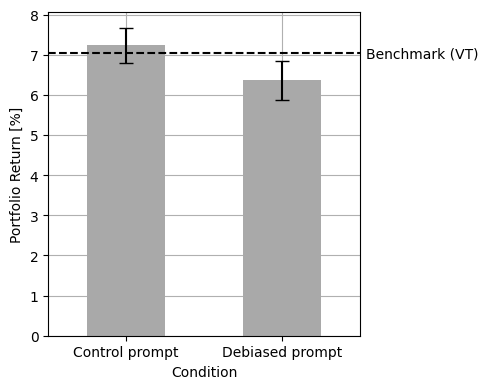

In [7]:
show_mean_errplot(portfolio_df, 'portfolio_return', 'Portfolio Return [%]', benchmark_return, 'Benchmark (VT)', 'cond')

               sum_sq     df          F    PR(>F)
label      466.451011    2.0  13.755141  0.000003
Residual  3001.126215  177.0        NaN       NaN
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
  high    low  -2.3601 0.0056  -4.137 -0.5832   True
  high medium   1.5556 0.0992 -0.2213  3.3325  False
   low medium   3.9157    0.0  2.1388  5.6926   True
----------------------------------------------------
group: ('low',) got t: -11.981355697538044 p_value: 0.0 dfs: 59 benchmark: 7.0324
group: ('medium',) got t: 3.5668818060174816 p_value: 0.0007 dfs: 59 benchmark: 7.0324
group: ('high',) got t: 0.04410861148966922 p_value: 0.965 dfs: 59 benchmark: 7.0324
means:
risk-taking
low       4.7068
medium    8.6225
high      7.0669
Name: portfolio_return, dtype: float64
stds:
risk-taking
low       1.5035
medium    3.4531
high      6.0566
Name: portfolio_return, dtype: float64
risk-tak

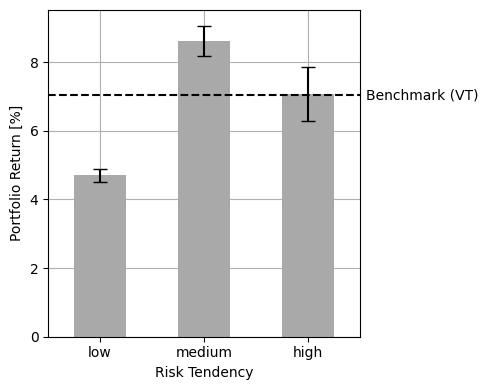

In [8]:
show_mean_errplot(portfolio_df, 'portfolio_return', 'Portfolio Return [%]',  benchmark_return, 'Benchmark (VT)', 'risk-taking')

               sum_sq     df         F    PR(>F)
label        0.605087    1.0  0.031066  0.860293
Residual  3466.972139  178.0       NaN       NaN
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
    15     30   0.9572 0.4609 -0.9445 2.8589  False
    15     50    0.223 0.9585 -1.6787 2.1248  False
    30     50  -0.7341 0.6332 -2.6359 1.1676  False
---------------------------------------------------
group: (15,) got t: -0.9532950240401699 p_value: 0.3443 dfs: 59 benchmark: 7.0324
group: (30,) got t: 0.5698553829163101 p_value: 0.5709 dfs: 59 benchmark: 7.0324
group: (50,) got t: -0.8972118756926559 p_value: 0.3733 dfs: 59 benchmark: 7.0324
means:
age
15    6.4054
30    7.3625
50    6.6284
Name: portfolio_return, dtype: float64
stds:
age
15    5.0953
30    4.4870
50    3.4882
Name: portfolio_return, dtype: float64
age
15    60
30    60
50    60
Name: portfolio_return, dtype: int64

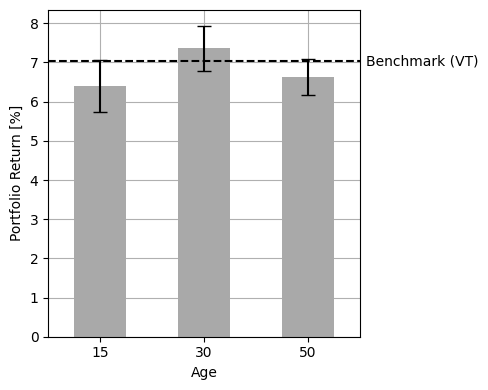

In [9]:
show_mean_errplot(portfolio_df, 'portfolio_return', 'Portfolio Return [%]', benchmark_return, 'Benchmark (VT)', 'age')

               sum_sq     df         F    PR(>F)
label      562.886985    5.0  6.743737  0.000009
Residual  2904.690242  174.0       NaN       NaN
                   Multiple Comparison of Means - Tukey HSD, FWER=0.05                   
         group1                    group2          meandiff p-adj   lower   upper  reject
-----------------------------------------------------------------------------------------
  (Control prompt, high)     (Control prompt, low)  -3.1526 0.0372 -6.1926 -0.1125   True
  (Control prompt, high)  (Control prompt, medium)   2.2091 0.2952 -0.8309  5.2492  False
  (Control prompt, high)   (Debiased prompt, high)  -0.9556 0.9446 -3.9957  2.0844  False
  (Control prompt, high)    (Debiased prompt, low)  -2.5233 0.1648 -5.5633  0.5168  False
  (Control prompt, high) (Debiased prompt, medium)  -0.0536    1.0 -3.0936  2.9865  False
   (Control prompt, low)  (Control prompt, medium)   5.3617    0.0  2.3216  8.4018   True
   (Control prompt, low)   (Debiased prompt

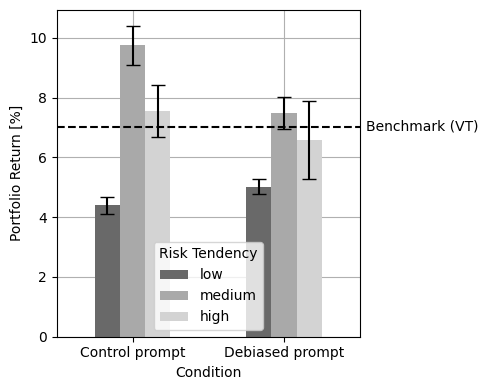

In [10]:
show_mean_errplot(portfolio_df, 'portfolio_return', 'Portfolio Return [%]', benchmark_return, 'Benchmark (VT)', 'cond', 'risk-taking')

### Portfolio Volatility

             sum_sq     df         F   PR(>F)
label      0.074915    1.0  0.335845  0.56297
Residual  39.705253  178.0       NaN      NaN
        Multiple Comparison of Means - Tukey HSD, FWER=0.05        
    group1          group2     meandiff p-adj  lower  upper  reject
-------------------------------------------------------------------
Control prompt Debiased prompt  -0.0408 0.563 -0.1797 0.0981  False
-------------------------------------------------------------------
group: ('Control prompt',) got t: 5.451591533210365 p_value: 0.0 dfs: 89 benchmark: 0.7562
group: ('Debiased prompt',) got t: 5.031751342149873 p_value: 0.0 dfs: 89 benchmark: 0.7562
means:
cond
Control prompt     1.0377
Debiased prompt    0.9969
Name: portfolio_std_dev, dtype: float64
stds:
cond
Control prompt     0.4900
Debiased prompt    0.4539
Name: portfolio_std_dev, dtype: float64
cond
Control prompt     90
Debiased prompt    90
Name: portfolio_std_dev, dtype: int64


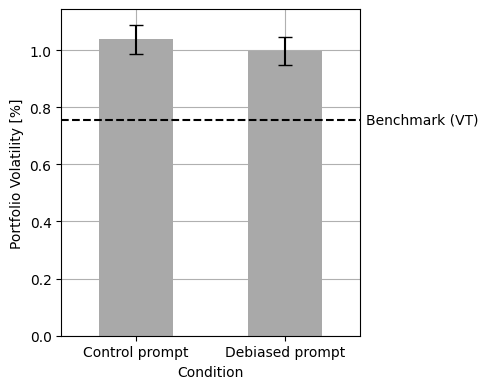

In [11]:
show_mean_errplot(portfolio_df, 'portfolio_std_dev', 'Portfolio Volatility [%]', benchmark_std, 'Benchmark (VT)', 'cond')

             sum_sq     df           F        PR(>F)
label     29.117552    2.0  241.676469  2.485696e-51
Residual  10.662616  177.0         NaN           NaN
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
  high    low  -0.9716   0.0 -1.0775 -0.8657   True
  high medium  -0.6269   0.0 -0.7328  -0.521   True
   low medium   0.3447   0.0  0.2388  0.4506   True
---------------------------------------------------
group: ('low',) got t: -13.703253025912183 p_value: 0.0 dfs: 59 benchmark: 0.7562
group: ('medium',) got t: 7.309734317971791 p_value: 0.0 dfs: 59 benchmark: 0.7562
group: ('high',) got t: 16.47942029521737 p_value: 0.0 dfs: 59 benchmark: 0.7562
means:
risk-taking
low       0.5786
medium    0.9233
high      1.5502
Name: portfolio_std_dev, dtype: float64
stds:
risk-taking
low       0.1004
medium    0.1771
high      0.3732
Name: portfolio_std_dev, dtype: float64
risk-taking


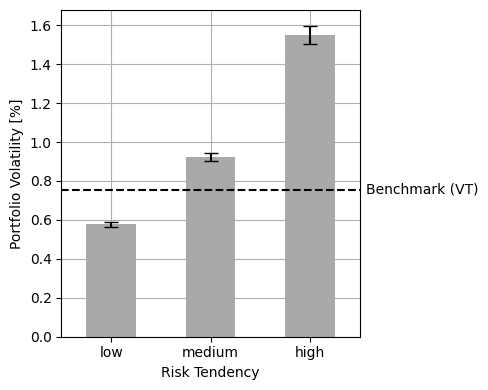

In [12]:
show_mean_errplot(portfolio_df, 'portfolio_std_dev', 'Portfolio Volatility [%]', benchmark_std, 'Benchmark (VT)', 'risk-taking')

             sum_sq     df         F   PR(>F)
label      0.556954    1.0  2.527527  0.11365
Residual  39.223214  178.0       NaN      NaN
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
    15     30  -0.1586 0.1554 -0.3608 0.0436  False
    15     50  -0.1449 0.2103 -0.3471 0.0573  False
    30     50   0.0137  0.986 -0.1885 0.2158  False
---------------------------------------------------
group: (15,) got t: 5.505527973225985 p_value: 0.0 dfs: 59 benchmark: 0.7562
group: (30,) got t: 3.813302446088249 p_value: 0.0003 dfs: 59 benchmark: 0.7562
group: (50,) got t: 3.5317177117402996 p_value: 0.0008 dfs: 59 benchmark: 0.7562
means:
age
15    1.1185
30    0.9599
50    0.9736
Name: portfolio_std_dev, dtype: float64
stds:
age
15    0.5098
30    0.4139
50    0.4768
Name: portfolio_std_dev, dtype: float64
age
15    60
30    60
50    60
Name: portfolio_std_dev, dtype: int64


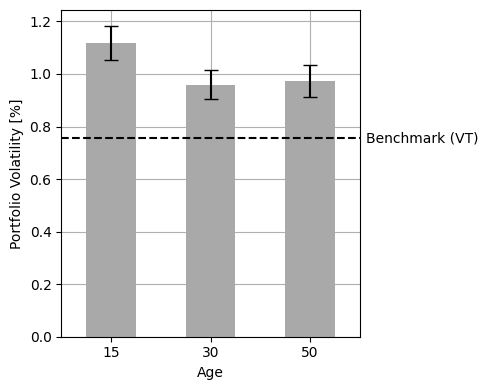

In [13]:
show_mean_errplot(portfolio_df, 'portfolio_std_dev', 'Portfolio Volatility [%]', benchmark_std, 'Benchmark (VT)', 'age')

             sum_sq     df          F        PR(>F)
label     29.347094    5.0  97.888586  1.072216e-48
Residual  10.433074  174.0        NaN           NaN
                   Multiple Comparison of Means - Tukey HSD, FWER=0.05                   
         group1                    group2          meandiff p-adj   lower   upper  reject
-----------------------------------------------------------------------------------------
  (Control prompt, high)     (Control prompt, low)  -1.0378    0.0   -1.22 -0.8556   True
  (Control prompt, high)  (Control prompt, medium)  -0.6359    0.0  -0.818 -0.4537   True
  (Control prompt, high)   (Debiased prompt, high)  -0.0909 0.7041 -0.2731  0.0913  False
  (Control prompt, high)    (Debiased prompt, low)  -0.9963    0.0 -1.1785 -0.8141   True
  (Control prompt, high) (Debiased prompt, medium)  -0.7088    0.0  -0.891 -0.5266   True
   (Control prompt, low)  (Control prompt, medium)   0.4019    0.0  0.2197  0.5841   True
   (Control prompt, low)   (Debias

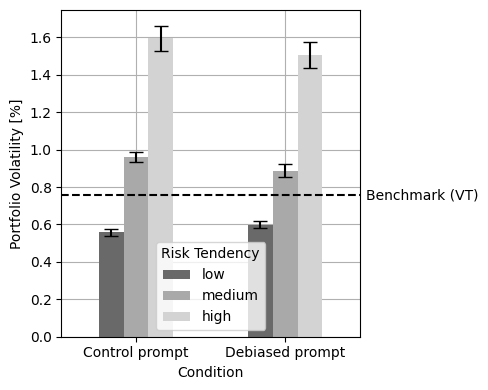

In [14]:
show_mean_errplot(portfolio_df, 'portfolio_std_dev', 'Portfolio Volatility [%]', benchmark_std, 'Benchmark (VT)', 'cond', 'risk-taking')

### Sharpe

In [15]:
print(portfolio_df.shape)
sharpe_df = portfolio_df.copy()
sharpe_df = sharpe_df.dropna()
print(sharpe_df.shape)

(180, 9)
(180, 9)


               sum_sq     df         F    PR(>F)
label       13.119398    1.0  0.991992  0.320608
Residual  2354.105249  178.0       NaN       NaN
        Multiple Comparison of Means - Tukey HSD, FWER=0.05         
    group1          group2     meandiff p-adj   lower  upper  reject
--------------------------------------------------------------------
Control prompt Debiased prompt  -0.5399 0.3206 -1.6098 0.5299  False
--------------------------------------------------------------------
group: ('Control prompt',) got t: -2.285587681667976 p_value: 0.0247 dfs: 89 benchmark: 3.6172
group: ('Debiased prompt',) got t: -4.245332145831892 p_value: 0.0001 dfs: 89 benchmark: 3.6172
means:
cond
Control prompt     2.6711
Debiased prompt    2.1312
Name: sharpe, dtype: float64
stds:
cond
Control prompt     3.9271
Debiased prompt    3.3209
Name: sharpe, dtype: float64
cond
Control prompt     90
Debiased prompt    90
Name: sharpe, dtype: int64


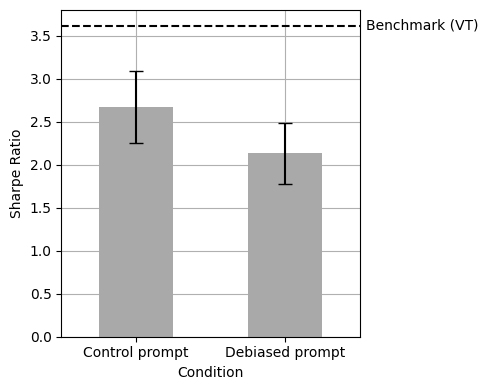

In [16]:
show_mean_errplot(sharpe_df, 'sharpe', 'Sharpe Ratio', benchmark_sharpe, 'Benchmark (VT)', 'cond')

               sum_sq     df         F        PR(>F)
label      497.932355    2.0  23.57417  8.379924e-10
Residual  1869.292292  177.0       NaN           NaN
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
  high    low  -1.5732 0.0236 -2.9756 -0.1708   True
  high medium    2.468 0.0001  1.0656  3.8704   True
   low medium   4.0411    0.0  2.6388  5.4435   True
----------------------------------------------------
group: ('low',) got t: -9.162476017885755 p_value: 0.0 dfs: 59 benchmark: 3.6172
group: ('medium',) got t: 2.2288548756867588 p_value: 0.0296 dfs: 59 benchmark: 3.6172
group: ('high',) got t: -3.147809425638835 p_value: 0.0026 dfs: 59 benchmark: 3.6172
means:
risk-taking
low       0.5297
medium    4.5708
high      2.1029
Name: sharpe, dtype: float64
stds:
risk-taking
low       2.6102
medium    3.3141
high      3.7265
Name: sharpe, dtype: float64
risk-taking
low     

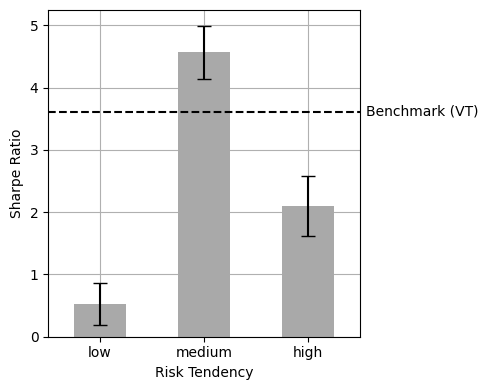

In [17]:
show_mean_errplot(sharpe_df, 'sharpe', 'Sharpe Ratio', benchmark_sharpe, 'Benchmark (VT)', 'risk-taking')

               sum_sq     df         F    PR(>F)
label        0.428196    1.0  0.032203  0.857786
Residual  2366.796451  178.0       NaN       NaN
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
    15     30   0.6382 0.6034  -0.934 2.2104  False
    15     50  -0.0564  0.996 -1.6286 1.5158  False
    30     50  -0.6946   0.55 -2.2668 0.8776  False
---------------------------------------------------
group: (15,) got t: -2.693299336106686 p_value: 0.0092 dfs: 59 benchmark: 3.6172
group: (30,) got t: -1.5638797965624056 p_value: 0.1232 dfs: 59 benchmark: 3.6172
group: (50,) got t: -3.838005524692997 p_value: 0.0003 dfs: 59 benchmark: 3.6172
means:
age
15    2.2072
30    2.8454
50    2.1508
Name: sharpe, dtype: float64
stds:
age
15    4.0553
30    3.8230
50    2.9596
Name: sharpe, dtype: float64
age
15    60
30    60
50    60
Name: sharpe, dtype: int64


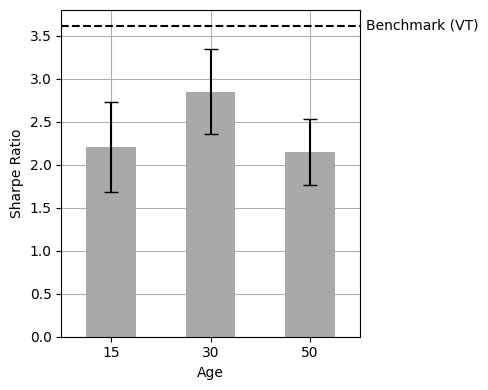

In [18]:
show_mean_errplot(sharpe_df, 'sharpe', 'Sharpe Ratio', benchmark_sharpe, 'Benchmark (VT)', 'age')

               sum_sq     df          F        PR(>F)
label      583.238574    5.0  11.377164  1.648165e-09
Residual  1783.986072  174.0        NaN           NaN
                   Multiple Comparison of Means - Tukey HSD, FWER=0.05                   
         group1                    group2          meandiff p-adj   lower   upper  reject
-----------------------------------------------------------------------------------------
  (Control prompt, high)     (Control prompt, low)  -2.2972 0.0658 -4.6797  0.0853  False
  (Control prompt, high)  (Control prompt, medium)    3.294 0.0014  0.9116  5.6765   True
  (Control prompt, high)   (Debiased prompt, high)  -0.4719 0.9928 -2.8544  1.9106  False
  (Control prompt, high)    (Debiased prompt, low)  -1.3211 0.6011 -3.7036  1.0614  False
  (Control prompt, high) (Debiased prompt, medium)     1.17 0.7178 -1.2125  3.5525  False
   (Control prompt, low)  (Control prompt, medium)   5.5912    0.0  3.2087  7.9737   True
   (Control prompt, low)   (

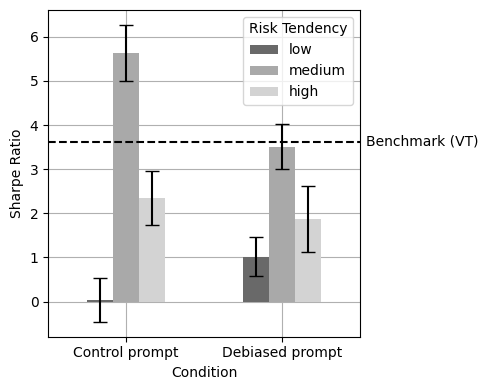

In [19]:
show_mean_errplot(sharpe_df, 'sharpe', 'Sharpe Ratio', benchmark_sharpe, 'Benchmark (VT)', 'cond', 'risk-taking')